### Cleaning The Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('data/raw/Algerian_forest_fires_dataset_UPDATE.csv', header=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [37]:
# Data Cleaning
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region


In [49]:
### Dropping the null row
df.drop(123, inplace=True)

In [53]:
### Resetting the Indexex
df=df.reset_index(drop=True)

In [ ]:
### Checking are these all numeric or not
df[~df['day'].str.isnumeric()]

In [36]:
### Findiny the mode for NAN class
df['Classes  ']=df['Classes  '].fillna(df['Classes  '].mode()[0])

In [ ]:
#### Creating a new Feature for the Region 
df.loc[:122,"Region"]=0
df.loc[122:,"Region"]=1

In [39]:
df['Region']=df['Region'].astype(int)

In [51]:
df[['day','month','year']]=df[['day','month','year']].astype(int)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 245 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          245 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      245 non-null    object
 14  Region       245 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 30.6+ KB


In [ ]:
df.head()
df['Rain ']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [74]:
df[['Temperature',' RH',' Ws','Rain ','FFMC','DMC','DC','ISI','BUI']]=df[['Temperature',' RH',' Ws','Rain ','FFMC','DMC','DC','ISI','BUI']].astype(float)

In [ ]:
### Remove the Space from the DC Column
df['DC']=df['DC'].str.replace(" ","")

In [89]:
pd.to_numeric(df['FWI'],errors='coerce').isnull().sum()

np.int64(1)

In [90]:
df.loc[pd.to_numeric(df['FWI'], errors='coerce').isnull(), 'FWI']

165    fire   
Name: FWI, dtype: object

In [ ]:
# assigning NAN to 165 value
df.loc[165,'FWI']=np.nan

In [97]:
df.loc[160:170]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
160,9,7,2012,36.0,43.0,15.0,1.9,82.3,9.4,9.90,3.2,9.0,3.1,fire,1
161,10,7,2012,34.0,51.0,16.0,3.8,77.5,8.0,9.50,2.0,7.7,1.3,not fire,1
162,11,7,2012,34.0,56.0,15.0,2.9,74.8,7.1,9.50,1.6,6.8,0.8,not fire,1
163,12,7,2012,36.0,44.0,13.0,0.0,90.1,12.6,19.40,8.3,12.5,9.6,fire,1
164,13,7,2012,39.0,45.0,13.0,0.6,85.2,11.3,10.40,4.2,10.9,4.7,fire,1
165,14,7,2012,37.0,37.0,18.0,0.2,88.9,12.9,14.69,12.5,10.4,NaN,fire,1
166,15,7,2012,34.0,45.0,17.0,0.0,90.5,18.0,24.10,10.9,17.7,14.1,fire,1
167,16,7,2012,31.0,83.0,17.0,0.0,84.5,19.4,33.10,4.7,19.2,7.3,fire,1
168,17,7,2012,32.0,81.0,17.0,0.0,84.6,21.1,42.30,4.7,20.9,7.7,fire,1
169,18,7,2012,33.0,68.0,15.0,0.0,86.1,23.9,51.60,5.2,23.9,9.1,fire,1


In [ ]:
df['FWI']=df['FWI'].astype(float)

In [104]:
df['FWI']=df['FWI'].fillna(df['FWI'].mean())

In [106]:
df['FWI'].isnull().sum()

np.int64(0)

In [110]:
#### Removing the Features Names Spaces
df.columns=df.columns.str.strip()

In [111]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [112]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,244.000000,244.000000,244.0,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,15.754098,7.500000,2012.0,32.172131,61.938525,15.504098,0.760656,77.887705,14.673361,49.288484,4.774180,16.664754,7.035391,0.500000
std,8.825059,1.112961,0.0,3.633843,14.884200,2.810178,1.999406,14.337571,12.368039,47.619393,4.175318,14.204824,7.425242,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.000000,14.000000,0.000000,72.075000,5.800000,13.275000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,7.500000,2012.0,32.000000,63.000000,15.000000,0.000000,83.500000,11.300000,33.100000,3.500000,12.250000,4.450000,0.500000
75%,23.000000,8.000000,2012.0,35.000000,73.250000,17.000000,0.500000,88.300000,20.750000,68.150000,7.300000,22.525000,11.375000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [ ]:
df['Classes']=df['Classes'].str.strip()

In [132]:
#### Saving the CSV File
df.to_csv('data/raw/Algerian_forest_fires_dataset_Cleaned.csv',index=False)

### Exploratory Data Analysis & Feature Engineering

In [136]:
## Dropping DAy, Month and Year
df_copy=df.drop(['day','month','year'],axis=1)

In [139]:
df_copy['Classes']=np.where(df_copy['Classes']=='not fire',0,1)

In [142]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  244 non-null    float64
 1   RH           244 non-null    float64
 2   Ws           244 non-null    float64
 3   Rain         244 non-null    float64
 4   FFMC         244 non-null    float64
 5   DMC          244 non-null    float64
 6   DC           244 non-null    float64
 7   ISI          244 non-null    float64
 8   BUI          244 non-null    float64
 9   FWI          244 non-null    float64
 10  Classes      244 non-null    int64  
 11  Region       244 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 23.0 KB


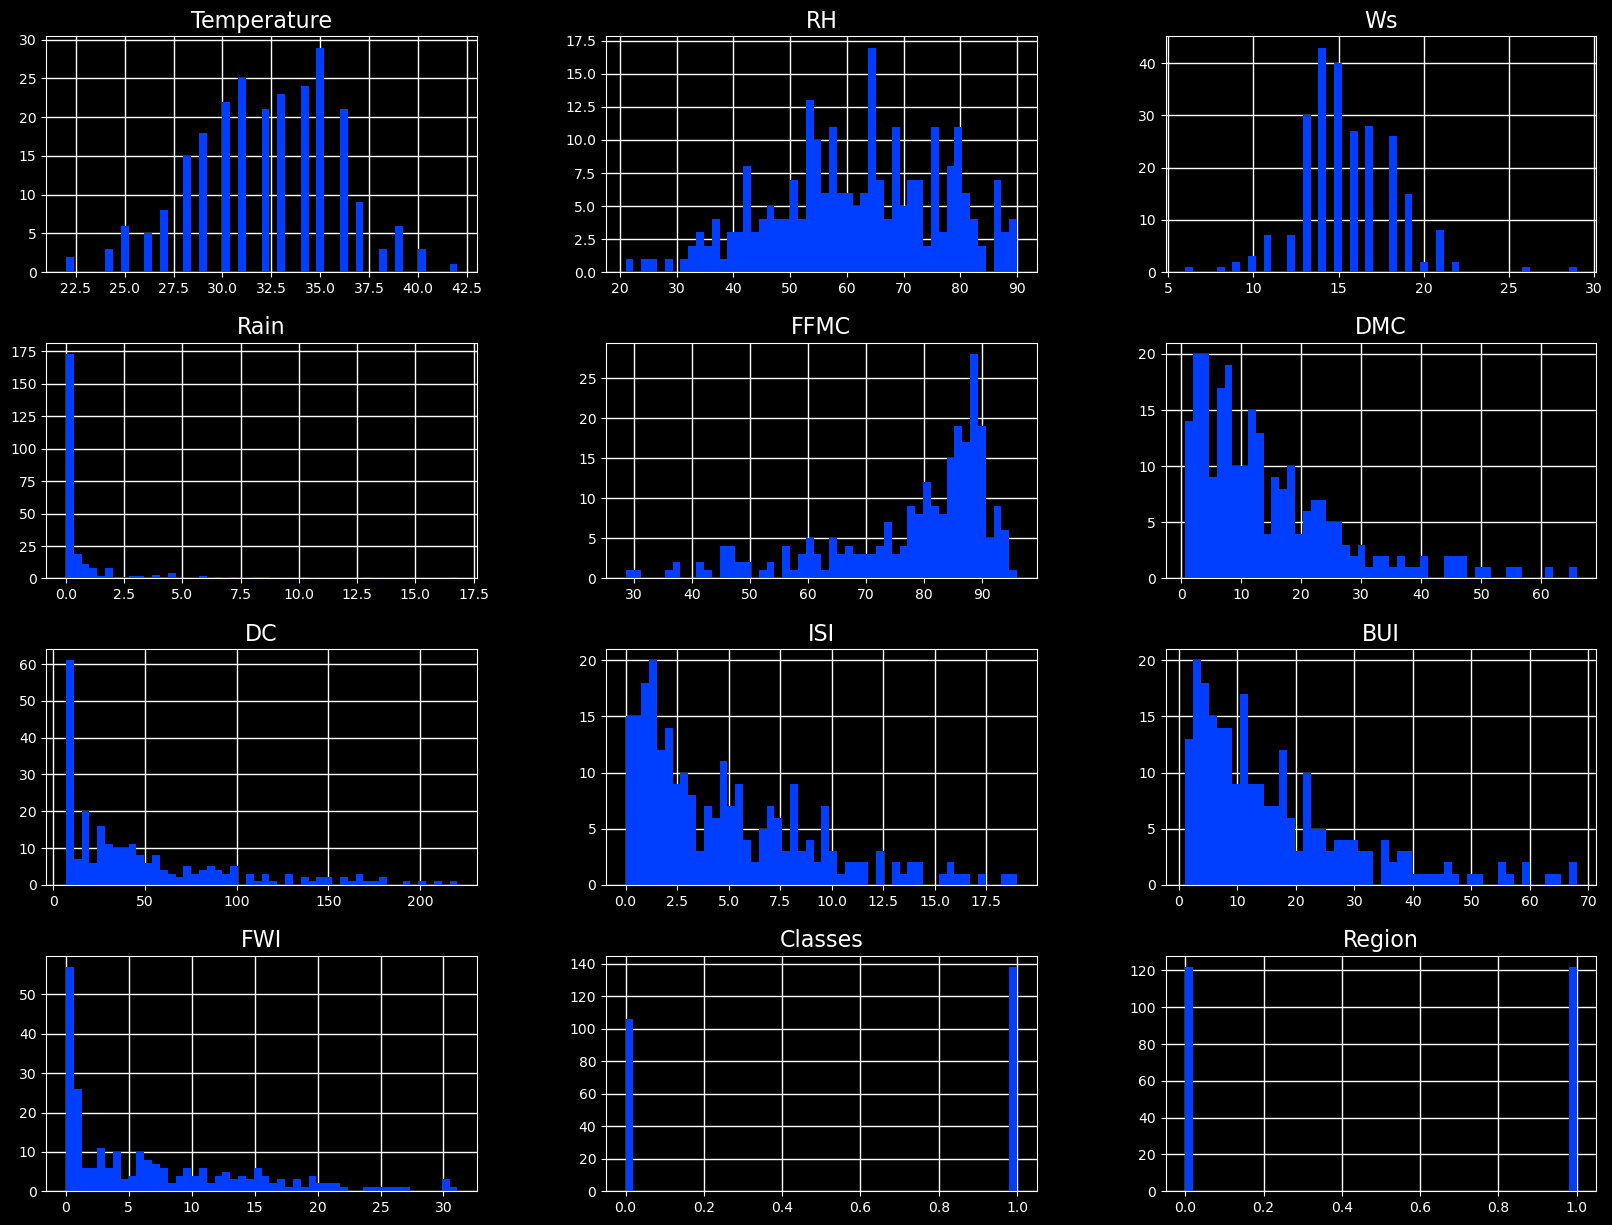

In [161]:
#### Visualization
plt.style.use('seaborn-v0_8-bright')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [163]:
perc=df_copy['Classes'].value_counts(normalize=True)*100

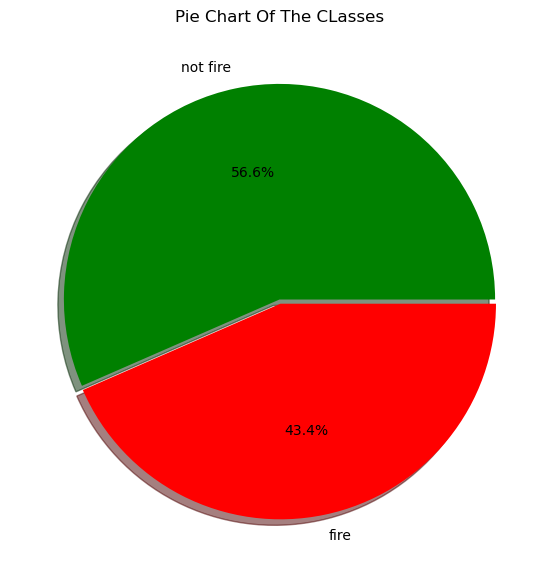

In [179]:
class_label=['not fire','fire']
plt.style.use('default')
plt.figure(figsize=(12,7))
plt.pie(perc,explode=(0,0.02),labels=class_label,autopct='%1.1f%%',colors=['Green','Red'],shadow=True)
plt.title('Pie Chart Of The CLasses')
plt.show()

In [180]:
### Correalation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.654443,-0.278132,-0.326786,0.677491,0.483105,0.370511,0.607551,0.455504,0.564599,0.518119,0.273496
RH,-0.654443,1.000000,0.236084,0.222968,-0.645658,-0.405133,-0.220344,-0.690637,-0.348587,-0.577577,-0.435023,-0.406424
Ws,-0.278132,0.236084,1.000000,0.170169,-0.163255,-0.001246,0.076253,0.015248,0.029756,0.032315,-0.066529,-0.176829
Rain,-0.326786,0.222968,0.170169,1.000000,-0.544045,-0.288548,-0.296808,-0.347105,-0.299171,-0.324369,-0.379449,-0.041080
FFMC,0.677491,-0.645658,-0.163255,-0.544045,1.000000,0.602391,0.503919,0.739730,0.589652,0.690289,0.770114,0.224680
DMC,0.483105,-0.405133,-0.001246,-0.288548,0.602391,1.000000,0.875362,0.674499,0.982073,0.875827,0.584188,0.191094
DC,0.370511,-0.220344,0.076253,-0.296808,0.503919,0.875362,1.000000,0.498926,0.941906,0.738714,0.507132,-0.081482
ISI,0.607551,-0.690637,0.015248,-0.347105,0.739730,0.674499,0.498926,1.000000,0.635891,0.916343,0.735511,0.268421
BUI,0.455504,-0.348587,0.029756,-0.299171,0.589652,0.982073,0.941906,0.635891,1.000000,0.857628,0.583882,0.087370
FWI,0.564599,-0.577577,0.032315,-0.324369,0.690289,0.875827,0.738714,0.916343,0.857628,1.000000,0.718079,0.196696


<Axes: >

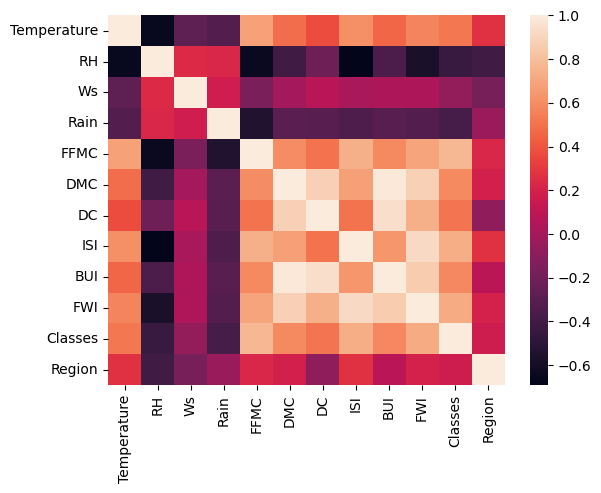

In [181]:
sns.heatmap(df_copy.corr())

Text(0.5, 0, 'Months')

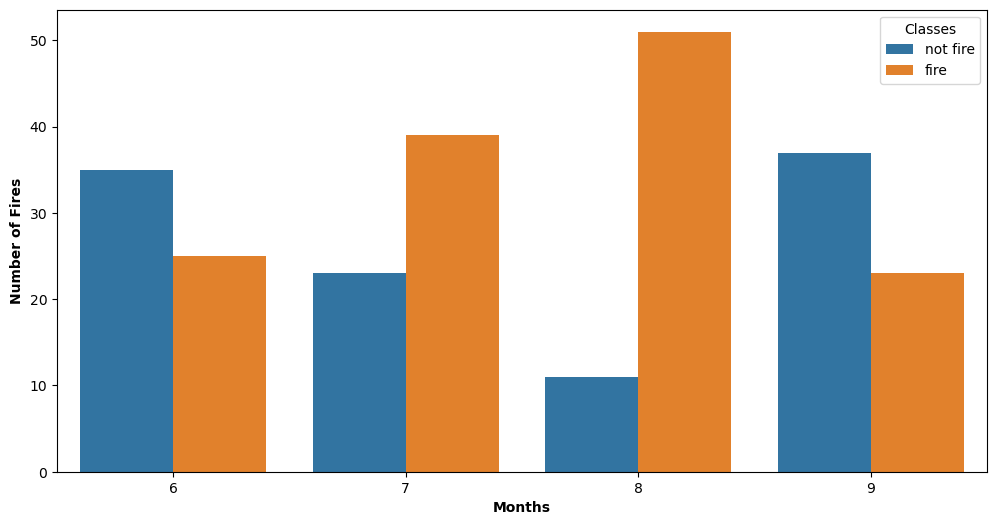

In [184]:
dftemp = df.loc[df['Region']==1]
plt.subplots(figsize=(12,6))
sns.countplot(x=df['month'],hue='Classes',data=df)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')